### Attention Test

In [1]:
import torch
import timm
import os
import pandas as pd
import numpy as np
from skimage import io
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from timm.data import resolve_data_config
from torchvision.transforms import v2
from timm.data.transforms_factory import create_transform
import torch.nn as nn
from torchvision import transforms
import cv2
import histomicstk as htk
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests
import torch
import timm
import cv2

import torch.nn.functional as F
from sklearn.preprocessing import normalize


d:\UofT\2025fall\OnSight\OnSight_Pathology\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Clustering

In [100]:
# =========================
# 1. Tissue Mask
# =========================
def get_tissue_mask_global(img, sat_thresh=10, val_thresh=250):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    sat = hsv[:, :, 1]
    val = hsv[:, :, 2]

    mask = (sat > sat_thresh) & (val < val_thresh)

   # kernel = np.ones((5, 5), np.uint8)
    #mask = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)

    return mask.astype(bool)
# model = timm.create_model('mobilenetv3_large_100', pretrained=True, features_only=True, out_indices=(1, 2, 3, 4))
# x = torch.randn(1, 3, 224, 224)
# features = model(x)

# # # 打印提取出的多尺度特征的形状
# # for i, feat in enumerate(features):
# #     print(f"Feature {i} shape: {feat.shape}")

# global_pool = nn.AdaptiveAvgPool2d((1, 1))
# flatten = nn.Flatten()                 # 移除多余的 1x1 维度

# feat3 = features[3]

# x = global_pool(feat3)      # 形状变成 [1, 960, 1, 1]
# embedding = flatten(x)      # 形状变成 [1, 960]

# print(f"Embedding shape: {embedding.shape}")
# =========================
# 2. Clustering Function
# =========================
def find_clusters(img, model, transform, device,feature_layer, sat_thresh=10, val_thresh=250,
                  patch_size=48, n_clusters=5, batch_size=128, tissue_threshold=0.95):

    h, w, c = img.shape
    h_steps = h // patch_size
    w_steps = w // patch_size

    if h_steps == 0 or w_steps == 0:
        return img, None, None, None

    tissue_mask = get_tissue_mask_global(img, sat_thresh=sat_thresh, val_thresh=val_thresh)

    global_pool = nn.AdaptiveAvgPool2d((1, 1))
    flatten = nn.Flatten()

    patches = []
    valid_indices = []

    # ---- Extract patches (only tissue) ----
    for i in range(h_steps):
        for j in range(w_steps):
            patch = img[i*patch_size:(i+1)*patch_size,
                        j*patch_size:(j+1)*patch_size]

            mask_patch = tissue_mask[i*patch_size:(i+1)*patch_size,
                                     j*patch_size:(j+1)*patch_size]

            # 只保留有组织的 patch
            if np.mean(mask_patch) > tissue_threshold:
                patches.append(patch)
                valid_indices.append((i, j))

    if len(patches) == 0:
        return img, None, None, None

    # ---- Extract features ----
    all_embeddings = []

    with torch.no_grad():
        for start_idx in range(0, len(patches), batch_size):
            batch_patches = patches[start_idx:start_idx + batch_size]

            batch_tensors = [transform(Image.fromarray(p)) for p in batch_patches]
            batch_tensor = torch.stack(batch_tensors).to(device)
            if feature_layer is not None:

                features = model(batch_tensor)  # (B, D)
                feat3 = features[feature_layer]
                #print(f"Batch {start_idx//batch_size}: feature shape {feat3.shape}")

                x = global_pool(feat3)      # 形状变成 [B, 960, 1, 1]
                embedding = flatten(x)      # 形状变成 [B, 960]
            else:
                embedding = model(batch_tensor)  # (B, D)


            all_embeddings.append(embedding.cpu().numpy())

    embeddings_matrix = np.concatenate(all_embeddings, axis=0)
    print("Embedding shape:", embeddings_matrix.shape)

    # ---- Normalize ----
    embeddings_matrix = normalize(embeddings_matrix, norm='l2')

    # ---- KMeans ----
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(embeddings_matrix) + 1  # 1 ~ n_clusters

    # ---- Rebuild full cluster map ----
    cluster_map = np.full((h_steps, w_steps), 0, dtype=np.int32)  # 背景 = 0

    for idx, (i, j) in enumerate(valid_indices):
        cluster_map[i, j] = cluster_labels[idx]

    # ---- Normalize to 0-255 ----
    cluster_map_norm = (cluster_map * (255 / n_clusters)).astype(np.uint8)

    # ---- Heatmap ----
    heatmap_bgr = cv2.applyColorMap(cluster_map_norm, cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)
    heatmap_resized = cv2.resize(heatmap_rgb, (w, h), interpolation=cv2.INTER_NEAREST)

    # ---- Overlay ----
    mask_3d = np.expand_dims(tissue_mask, axis=-1)
    blended = cv2.addWeighted(img, 0.6, heatmap_resized, 0.4, 0)
    overlay_img = np.where(mask_3d, blended, img)

    return overlay_img, cluster_labels, patches, valid_indices

def visualize_cluster_patches(patches, cluster_labels, n_clusters,
                              patches_per_cluster=16, random_seed=42):
    """
    patches: list of RGB patch images
    cluster_labels: np.array, shape (N,), values in [1, n_clusters]
    n_clusters: int
    patches_per_cluster: 每个cluster显示多少个patch
    """
    if patches is None or cluster_labels is None:
        print("No patches or cluster labels to visualize.")
        return

    rng = np.random.default_rng(random_seed)

    for cluster_id in range(1, n_clusters + 1):
        cluster_indices = np.where(cluster_labels == cluster_id)[0]

        if len(cluster_indices) == 0:
            print(f"Cluster {cluster_id}: no patches")
            continue

        # 随机抽样
        n_show = min(patches_per_cluster, len(cluster_indices))
        sampled_indices = rng.choice(cluster_indices, size=n_show, replace=False)

        # 自动算网格大小
        n_cols = 4
        n_rows = int(np.ceil(n_show / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
        axes = np.array(axes).reshape(-1)

        for ax_idx, patch_idx in enumerate(sampled_indices):
            axes[ax_idx].imshow(patches[patch_idx])
            axes[ax_idx].axis('off')

        # 多余子图关掉
        for ax_idx in range(n_show, len(axes)):
            axes[ax_idx].axis('off')

        plt.suptitle(f"Cluster {cluster_id} - {len(cluster_indices)} patches", fontsize=16)
        plt.tight_layout()
        plt.show()
  

### Use function

Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Embedding shape: (1329, 48)


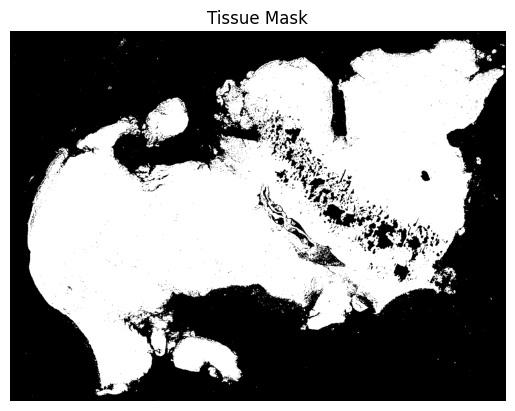

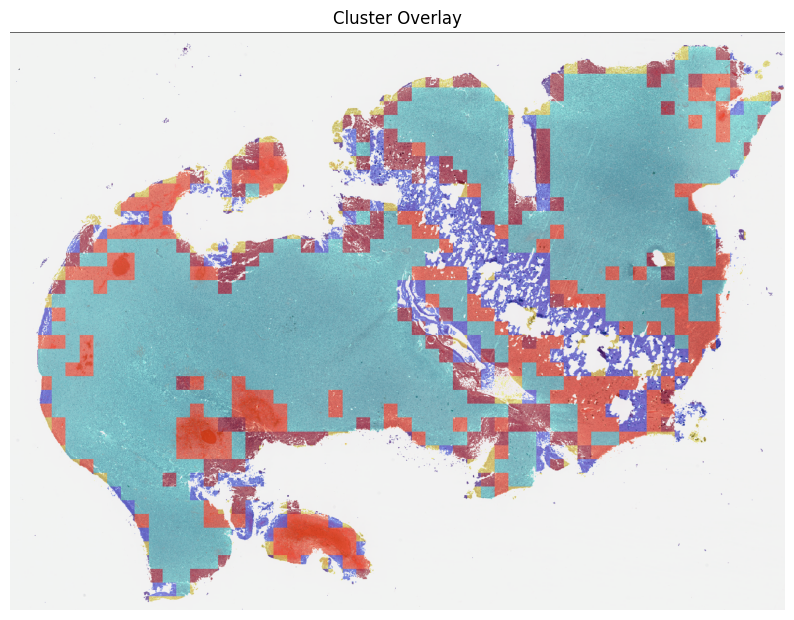

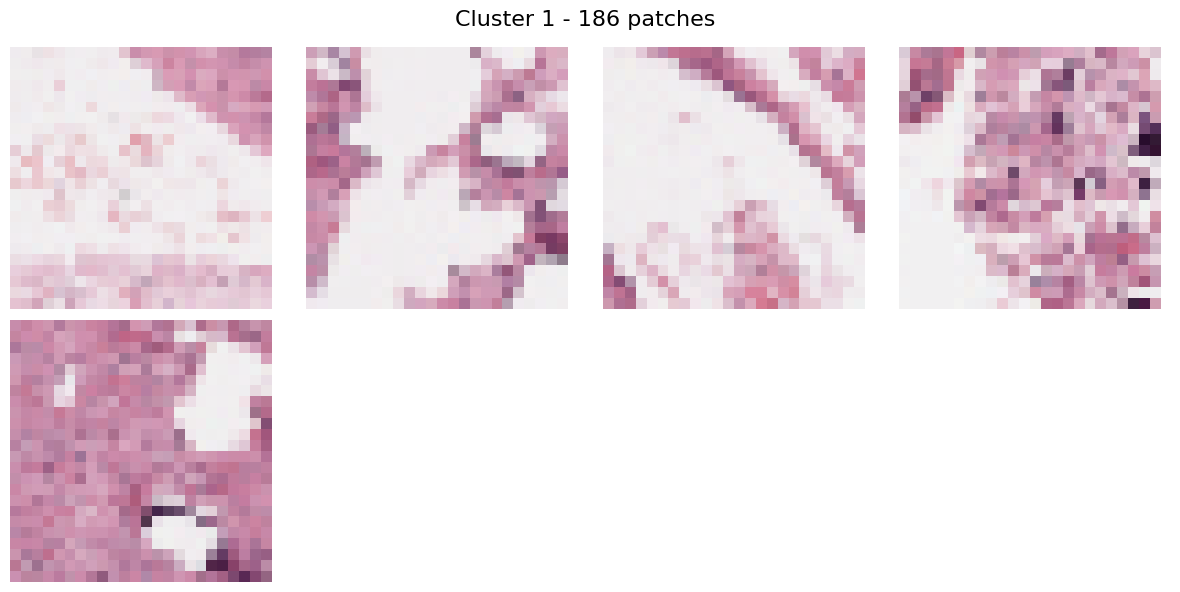

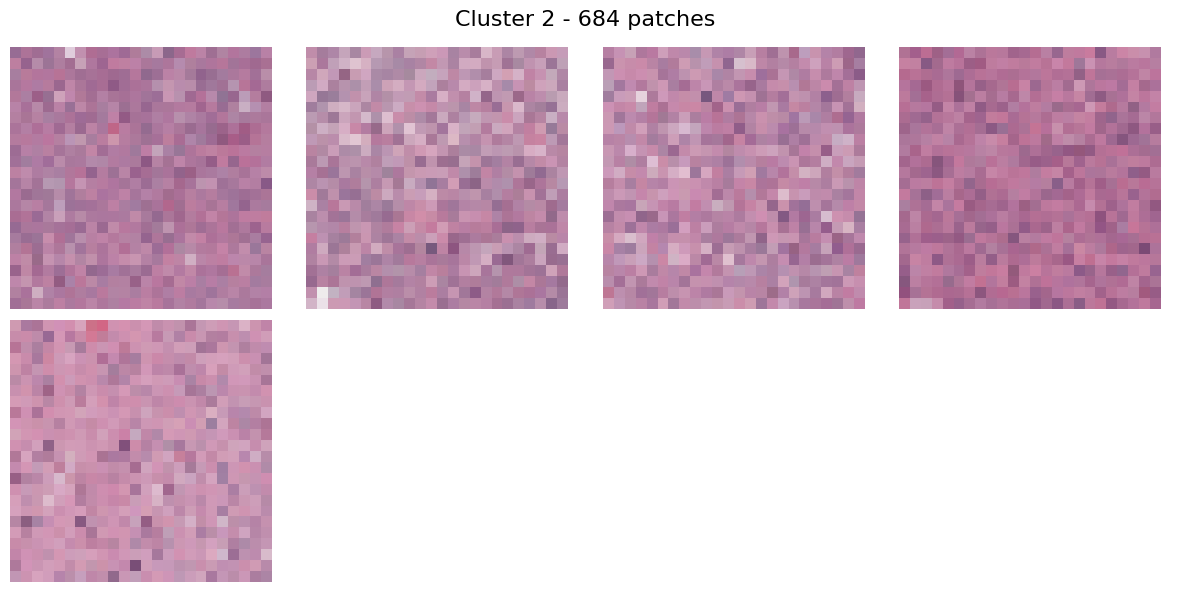

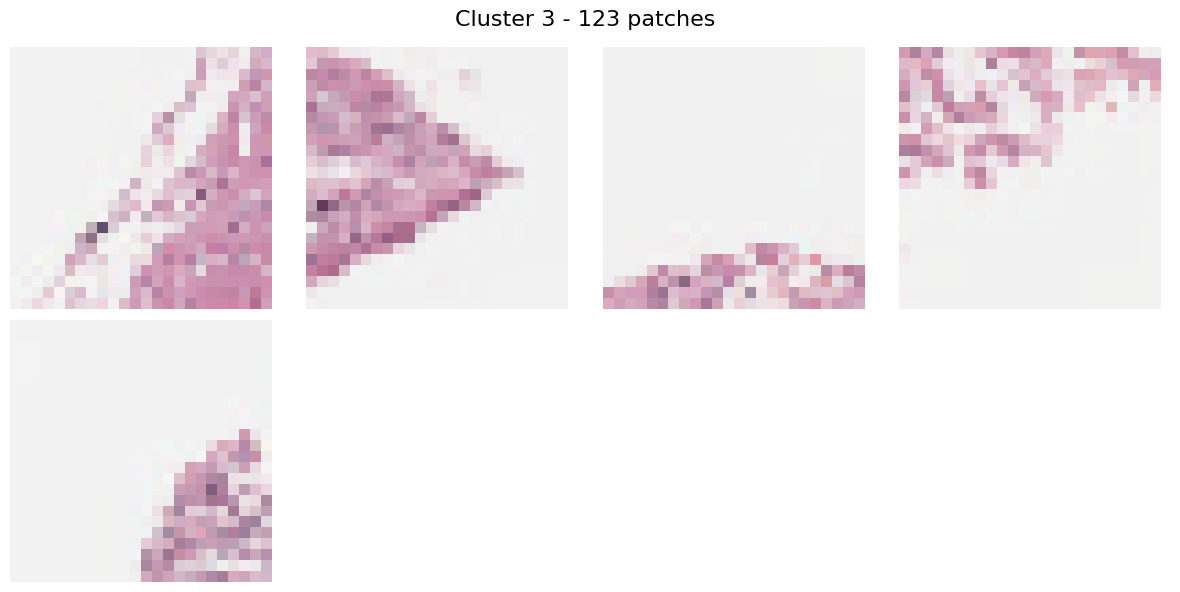

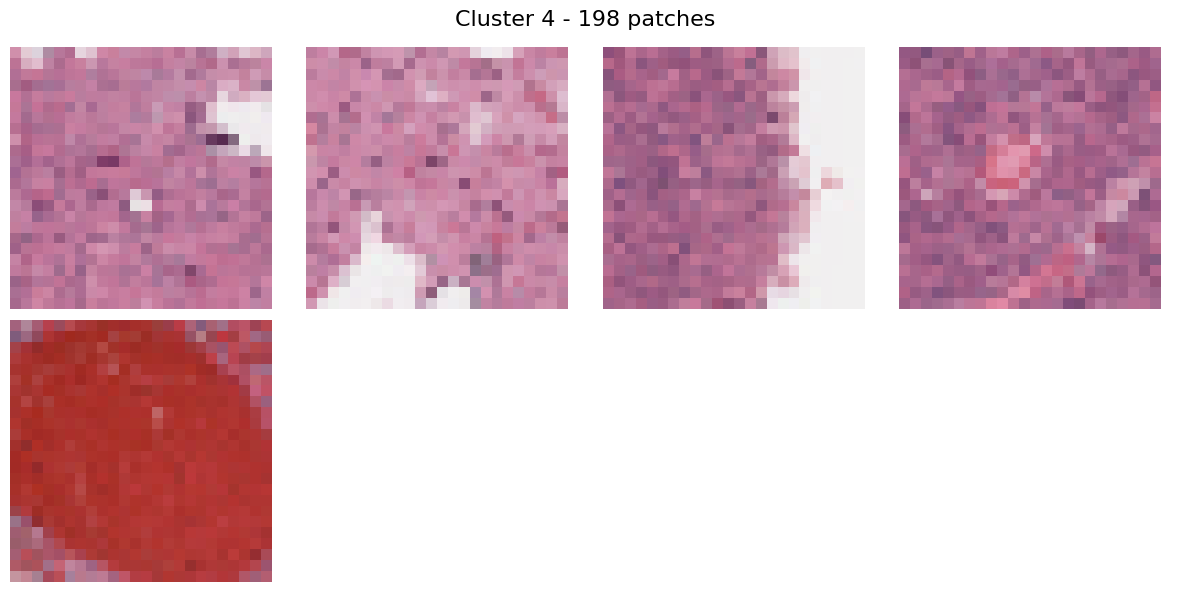

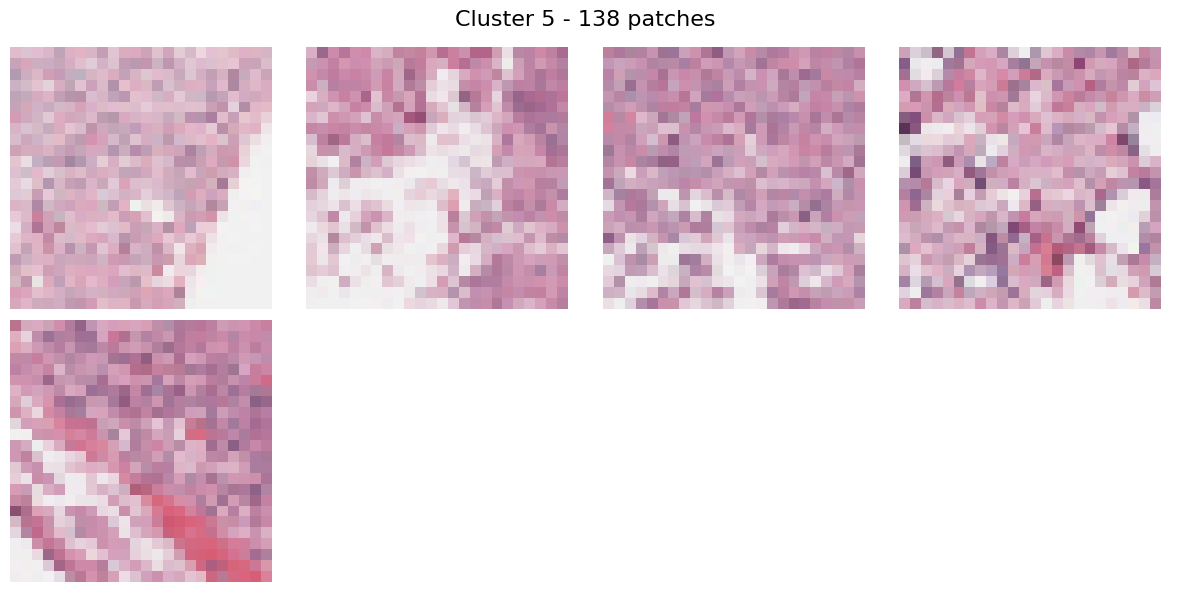

In [107]:
img_path = r"D:\UofT\2025fall\OnSight\OnSight_Pathology\wsi_lgg2.png"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

tissue_mask = get_tissue_mask_global(img)
plt.imshow(tissue_mask, cmap='gray')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# model = timm.create_model(
#     'mobilenetv3_small_100.lamb_in1k',
#     pretrained=True,
#     num_classes=0
# ).to(device)
# model = timm.create_model(
# model_name="hf-hub:1aurent/vit_base_patch16_224.kaiko_ai_towards_large_pathology_fms",
# #dynamic_img_size=True,
# pretrained=True,
# num_classes=0).to(device).eval()
model = timm.create_model(
    'mobilenetv3_small_100.lamb_in1k',
    pretrained=True,
    features_only=True,
    out_indices=(1, 2, 3, 4)
).to(device).eval()

config = resolve_data_config({}, model=model)
transform = create_transform(**config)
n_clusters = 5
overlay_img, cluster_labels, patches, valid_indices = find_clusters(
    img,
    model,
    transform,
    device,
    feature_layer=2,   # 试试不同层的特征
    sat_thresh=10,
    val_thresh=250,
    patch_size=24,
    n_clusters=n_clusters,
    batch_size=128,
    tissue_threshold=0.1
)

plt.imshow(get_tissue_mask_global(img, sat_thresh=10, val_thresh=250), cmap='gray')
plt.title("Tissue Mask")
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 10))
plt.imshow(overlay_img)
plt.title("Cluster Overlay")
plt.axis('off')
plt.show()

# 可视化每个 cluster 的 patch
visualize_cluster_patches(
    patches,
    cluster_labels,
    n_clusters=n_clusters,
    patches_per_cluster=5
)

In [97]:
model = timm.create_model(
    'mobilenetv3_small_100.lamb_in1k',
    pretrained=True,
    features_only=True,
    out_indices=(1, 2, 3, 4)
).to(device).eval()


Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [29]:
features = model(torch.randn(1, 3, 224, 224))

# 定义全局平均池化层和展平层
global_pool = nn.AdaptiveAvgPool2d(1)  # 把 7x7 变成 1x1
flatten = nn.Flatten()                 # 移除多余的 1x1 维度

feat3 = features[3]

x = global_pool(feat3)      # 形状变成 [1, 960, 1, 1]
embedding = flatten(x)      # 形状变成 [1, 960]

print(f"Embedding shape: {embedding.shape}")

Embedding shape: torch.Size([1, 960])
